<a href="https://colab.research.google.com/github/hv-0519/Broskies_Task1/blob/main/proj1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install prophet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [5]:
# Load all 3 datasets
confirmed = pd.read_csv('/content/time_series_covid19_confirmed_global.csv')
deaths    = pd.read_csv('/content/time_series_covid19_deaths_global.csv')
recovered = pd.read_csv('/content/time_series_covid19_recovered_global.csv')

# Melt from wide format (dates as columns) to long format
def melt_df(df, value_name):
    df = df.drop(columns=['Province/State', 'Lat', 'Long'])
    df = df.groupby('Country/Region').sum()
    df = df.reset_index()
    df = df.melt(id_vars='Country/Region', var_name='Date', value_name=value_name)
    df['Date'] = pd.to_datetime(df['Date'])
    return df

confirmed_long = melt_df(confirmed, 'Confirmed')
deaths_long    = melt_df(deaths,    'Deaths')
recovered_long = melt_df(recovered, 'Recovered')

# Merge into single dataframe
df = confirmed_long.merge(deaths_long, on=['Country/Region', 'Date'])
df = df.merge(recovered_long, on=['Country/Region', 'Date'])

# Add useful columns
df['Active']        = df['Confirmed'] - df['Deaths'] - df['Recovered']
df['Mortality_Rate'] = (df['Deaths'] / df['Confirmed'].replace(0, np.nan)) * 100

print("✅ Data loaded and cleaned!")
print(f"   Shape: {df.shape}")
print(f"   Countries: {df['Country/Region'].nunique()}")
print(f"   Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()

✅ Data loaded and cleaned!
   Shape: (229743, 7)
   Countries: 201
   Date range: 2020-01-22 → 2023-03-09


,Country/Region,Date,Confirmed,Deaths,Recovered,Active,Mortality_Rate
0,Afghanistan,2020-01-22,0,0,0,0,NaN
1,Albania,2020-01-22,0,0,0,0,NaN
2,Algeria,2020-01-22,0,0,0,0,NaN
3,Andorra,2020-01-22,0,0,0,0,NaN
4,Angola,2020-01-22,0,0,0,0,NaN


In [6]:
# Latest global totals
latest = df.groupby('Date').sum().reset_index()
last_date = latest['Date'].max()
last_row  = latest[latest['Date'] == last_date].iloc[0]

print("=" * 40)
print(f"  📅 Latest Date   : {last_date.date()}")
print(f"  🦠 Total Confirmed: {int(last_row['Confirmed']):,}")
print(f"  💀 Total Deaths   : {int(last_row['Deaths']):,}")
print(f"  💚 Total Recovered: {int(last_row['Recovered']):,}")
print(f"  🟡 Active Cases   : {int(last_row['Active']):,}")
print("=" * 40)

  📅 Latest Date   : 2023-03-09
  🦠 Total Confirmed: 676,570,149
  💀 Total Deaths   : 6,881,802
  💚 Total Recovered: 0
  🟡 Active Cases   : 669,688,347


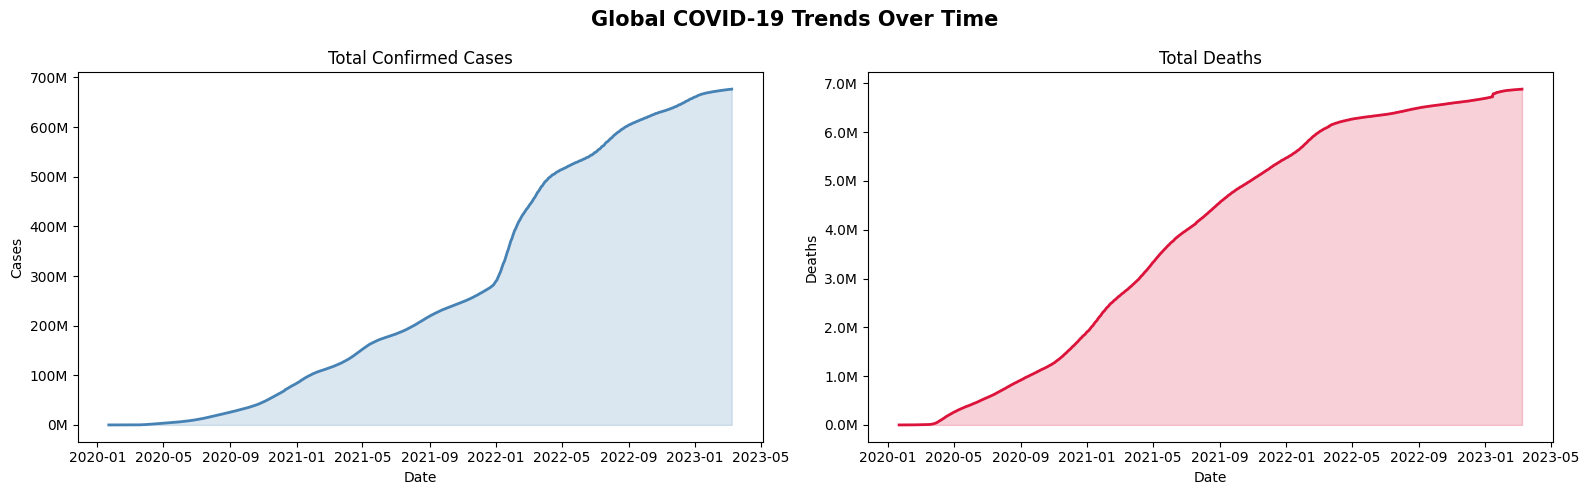

✅ Saved: viz1_global_trends.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Global COVID-19 Trends Over Time', fontsize=15, fontweight='bold')

# Confirmed
axes[0].plot(latest['Date'], latest['Confirmed'], color='steelblue', linewidth=2)
axes[0].fill_between(latest['Date'], latest['Confirmed'], alpha=0.2, color='steelblue')
axes[0].set_title('Total Confirmed Cases')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cases')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Deaths
axes[1].plot(latest['Date'], latest['Deaths'], color='crimson', linewidth=2)
axes[1].fill_between(latest['Date'], latest['Deaths'], alpha=0.2, color='crimson')
axes[1].set_title('Total Deaths')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Deaths')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('viz1_global_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz1_global_trends.png")

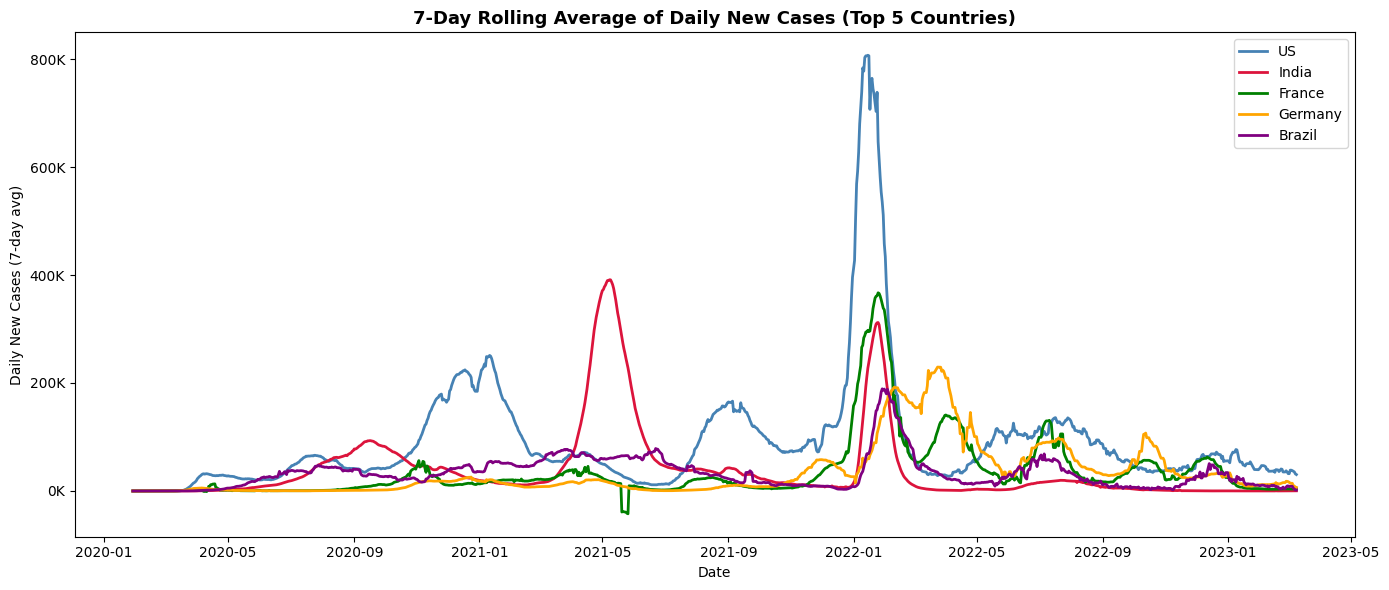

✅ Saved: viz3_rolling_average.png


In [8]:
top5_countries = df[df['Date'] == df['Date'].max()] \
                 .groupby('Country/Region')['Confirmed'].max() \
                 .sort_values(ascending=False).head(5).index.tolist()

plt.figure(figsize=(14, 6))
colors = ['steelblue', 'crimson', 'green', 'orange', 'purple']

for country, color in zip(top5_countries, colors):
    country_df = df[df['Country/Region'] == country].copy()
    country_df = country_df.sort_values('Date')
    country_df['Daily_New'] = country_df['Confirmed'].diff()
    country_df['Rolling_7'] = country_df['Daily_New'].rolling(7).mean()
    plt.plot(country_df['Date'], country_df['Rolling_7'],
             label=country, color=color, linewidth=2)

plt.title('7-Day Rolling Average of Daily New Cases (Top 5 Countries)',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily New Cases (7-day avg)')
plt.legend()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('viz3_rolling_average.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz3_rolling_average.png")

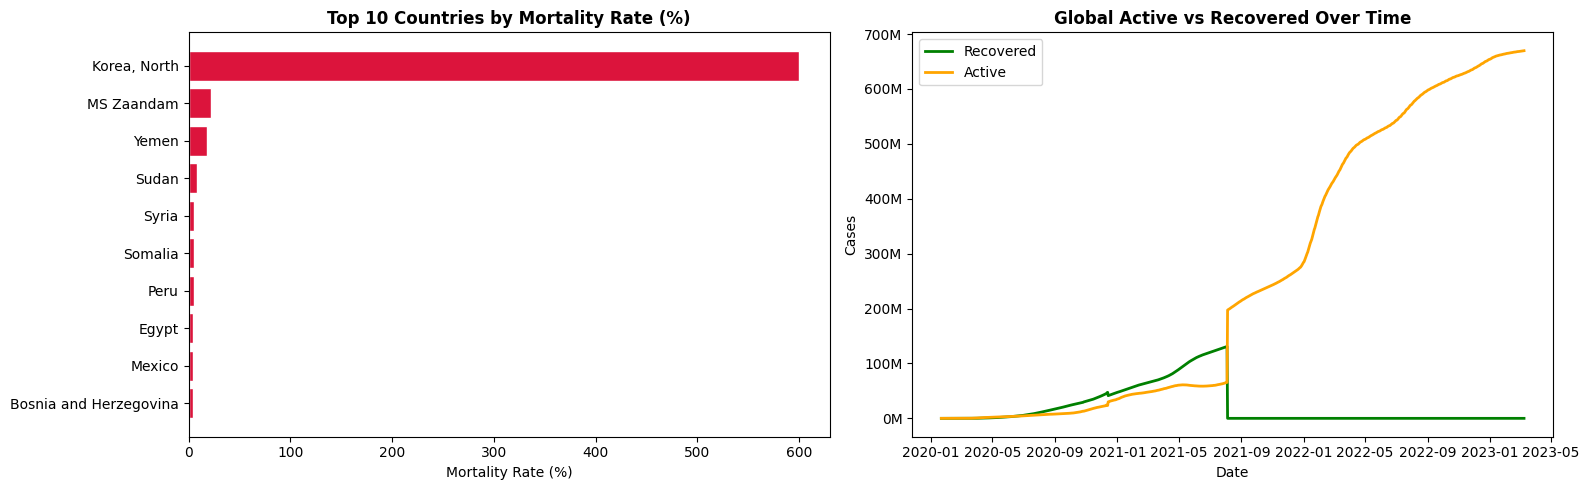

✅ Saved: viz4_mortality_active.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mortality rate - top 10 countries latest
mort = df[df['Date'] == df['Date'].max()] \
       .groupby('Country/Region')[['Deaths', 'Confirmed']].max()
mort['Mortality_Rate'] = (mort['Deaths'] / mort['Confirmed'].replace(0, np.nan)) * 100
mort = mort.sort_values('Mortality_Rate', ascending=False).head(10)

axes[0].barh(mort.index[::-1], mort['Mortality_Rate'][::-1], color='crimson', edgecolor='white')
axes[0].set_title('Top 10 Countries by Mortality Rate (%)', fontweight='bold')
axes[0].set_xlabel('Mortality Rate (%)')

# Global Active vs Recovered over time
axes[1].plot(latest['Date'], latest['Recovered'], color='green',  linewidth=2, label='Recovered')
axes[1].plot(latest['Date'], latest['Active'],    color='orange', linewidth=2, label='Active')
axes[1].set_title('Global Active vs Recovered Over Time', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cases')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('viz4_mortality_active.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz4_mortality_active.png")

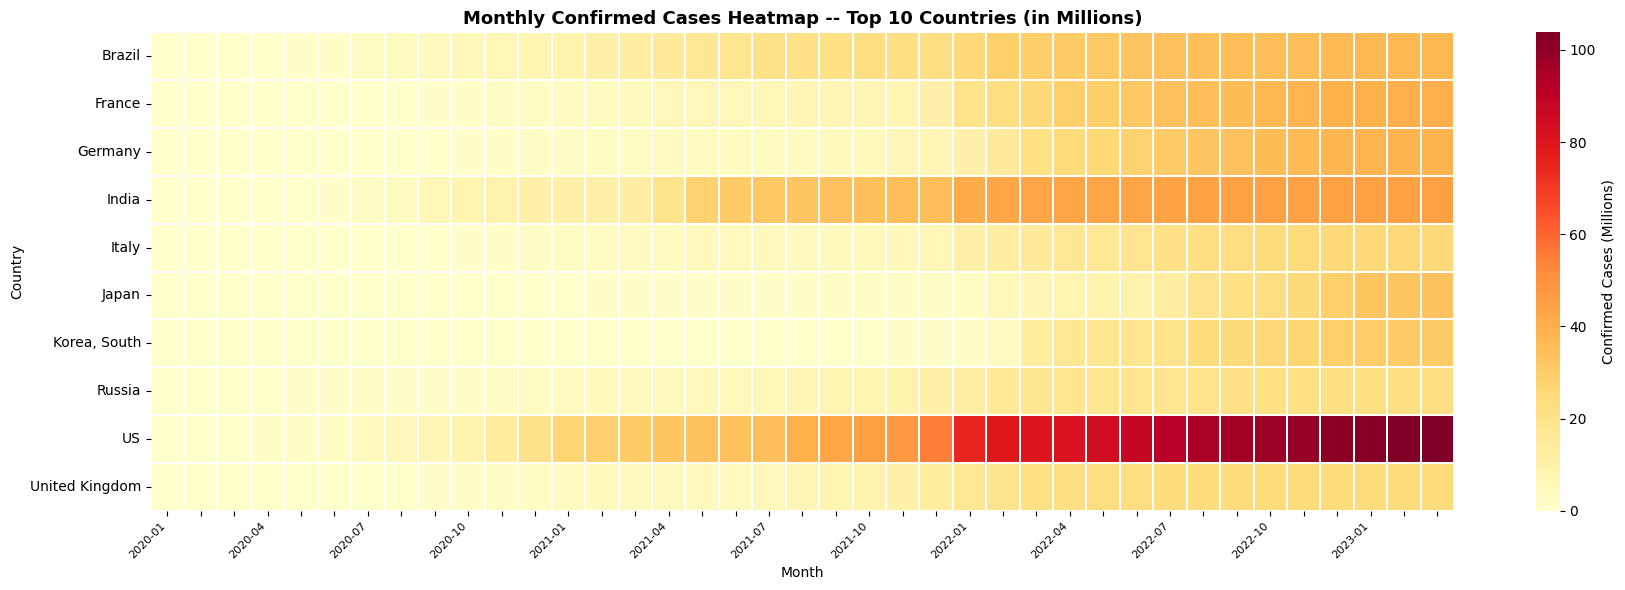

✅ Saved: viz5_heatmap.png


In [10]:
top10_list = df[df['Date'] == df['Date'].max()] \
             .groupby('Country/Region')['Confirmed'].max() \
             .sort_values(ascending=False).head(10).index.tolist()

heat_df = df[df['Country/Region'].isin(top10_list)].copy()
heat_df['YearMonth'] = heat_df['Date'].dt.to_period('M')
heat_pivot = heat_df.groupby(['Country/Region', 'YearMonth'])['Confirmed'].max().unstack()
heat_pivot.columns = heat_pivot.columns.astype(str)

# Keep every 3rd month label for readability
cols = heat_pivot.columns.tolist()
xtick_labels = [c if i % 3 == 0 else '' for i, c in enumerate(cols)]

plt.figure(figsize=(18, 6))
sns.heatmap(heat_pivot / 1e6, cmap='YlOrRd', linewidths=0.3,
            xticklabels=xtick_labels, yticklabels=True,
            cbar_kws={'label': 'Confirmed Cases (Millions)'})
plt.title('Monthly Confirmed Cases Heatmap -- Top 10 Countries (in Millions)',
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Country')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('viz5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz5_heatmap.png")

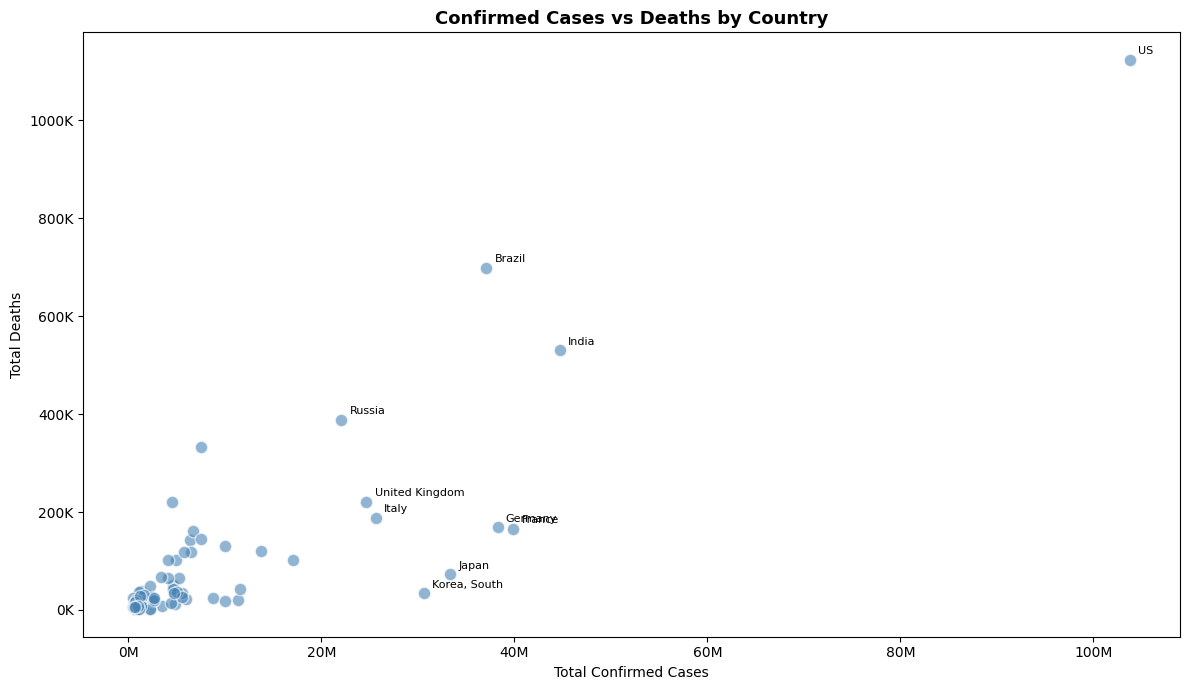

✅ Saved: viz6_scatter.png


In [11]:
scatter_df = df[df['Date'] == df['Date'].max()] \
             .groupby('Country/Region')[['Confirmed', 'Deaths']].max().reset_index()
scatter_df = scatter_df[scatter_df['Confirmed'] > 500000]

plt.figure(figsize=(12, 7))
plt.scatter(scatter_df['Confirmed'], scatter_df['Deaths'],
            alpha=0.6, color='steelblue', edgecolors='white', s=80)

# Label top 10 only
for _, row in scatter_df.nlargest(10, 'Confirmed').iterrows():
    plt.annotate(row['Country/Region'],
                 (row['Confirmed'], row['Deaths']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)

plt.title('Confirmed Cases vs Deaths by Country', fontsize=13, fontweight='bold')
plt.xlabel('Total Confirmed Cases')
plt.ylabel('Total Deaths')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('viz6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz6_scatter.png")

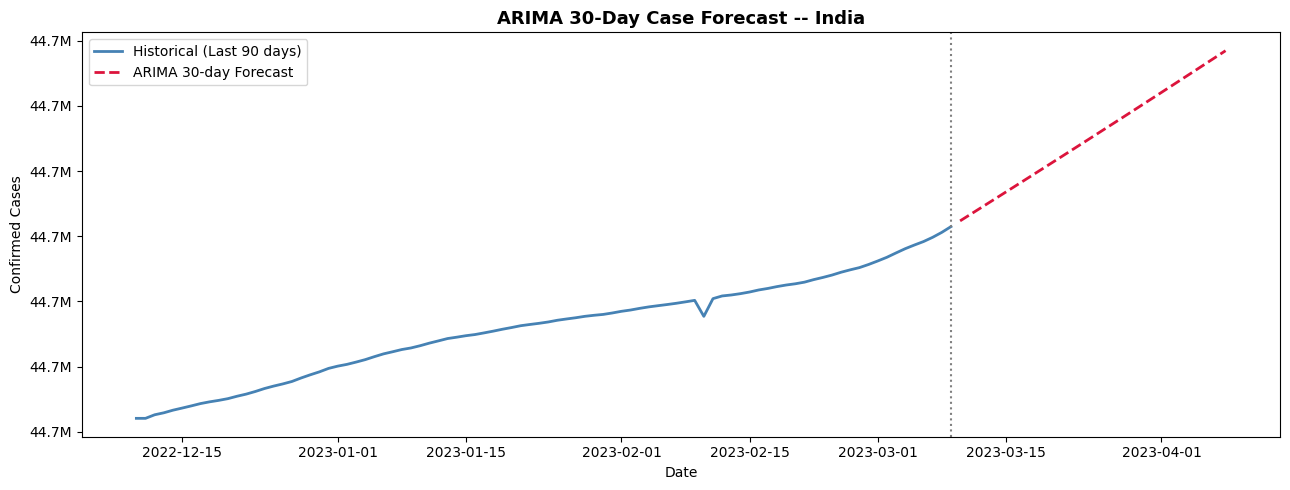

✅ Saved: viz7_arima_forecast.png


In [12]:
country = 'India'
country_df = df[df['Country/Region'] == country].groupby('Date')['Confirmed'].max()
country_df = country_df.asfreq('D').fillna(method='ffill')

# Use last 90 days for training
train = country_df[-90:]

model = ARIMA(train, order=(5, 2, 1))
result = model.fit()
forecast = result.forecast(steps=30)
forecast_index = pd.date_range(train.index[-1] + pd.Timedelta(days=1), periods=30)

plt.figure(figsize=(13, 5))
plt.plot(train.index, train.values, label='Historical (Last 90 days)',
         color='steelblue', linewidth=2)
plt.plot(forecast_index, forecast.values, label='ARIMA 30-day Forecast',
         color='crimson', linewidth=2, linestyle='--')
plt.axvline(train.index[-1], color='gray', linestyle=':', linewidth=1.5)
plt.title(f'ARIMA 30-Day Case Forecast -- {country}', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('viz7_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz7_arima_forecast.png")

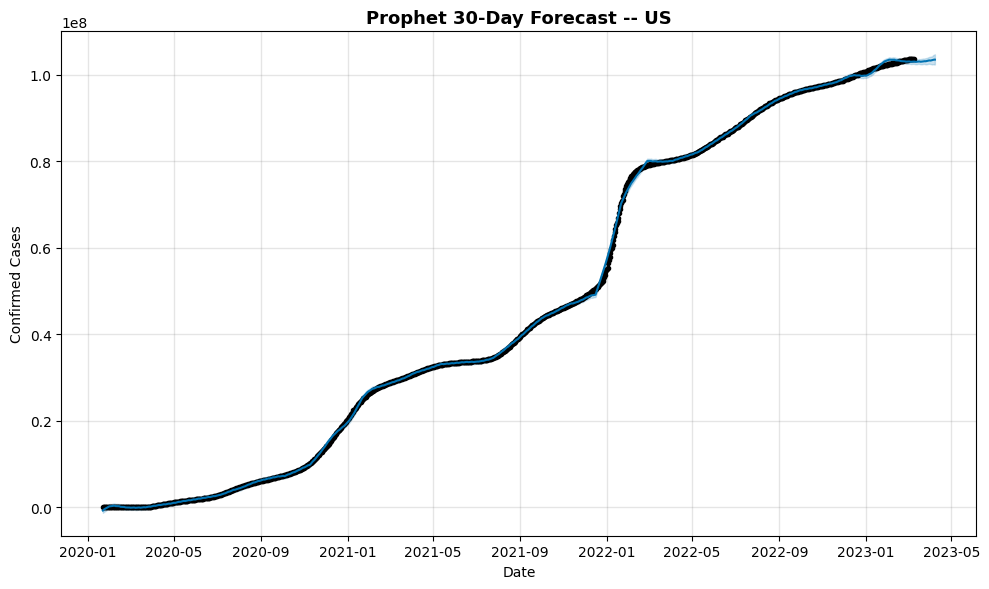

✅ Saved: viz8_prophet_forecast.png


In [13]:
country = 'US'
prophet_df = df[df['Country/Region'] == country].groupby('Date')['Confirmed'].max().reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df = prophet_df[prophet_df['y'] > 0]

model_p = Prophet(daily_seasonality=False, yearly_seasonality=True,
                  weekly_seasonality=True, changepoint_prior_scale=0.05)
model_p.fit(prophet_df)

future    = model_p.make_future_dataframe(periods=30)
forecast_p = model_p.predict(future)

fig = model_p.plot(forecast_p)
plt.title(f'Prophet 30-Day Forecast -- {country}', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.tight_layout()
plt.savefig('viz8_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz8_prophet_forecast.png")

In [14]:
print("=" * 55)
print("       COVID-19 GLOBAL ANALYSIS — FINAL REPORT")
print("=" * 55)

total_countries = df['Country/Region'].nunique()
date_range      = f"{df['Date'].min().date()} to {df['Date'].max().date()}"
total_records   = len(df)
global_latest   = df.groupby('Date').sum().iloc[-1]

print(f"\n📊 Dataset Overview")
print(f"   Countries Analyzed : {total_countries}")
print(f"   Date Range         : {date_range}")
print(f"   Total Records      : {total_records:,}")

print(f"\n🌍 Global Totals (Latest)")
print(f"   Confirmed  : {int(global_latest['Confirmed']):,}")
print(f"   Deaths     : {int(global_latest['Deaths']):,}")
print(f"   Recovered  : {int(global_latest['Recovered']):,}")
print(f"   Active     : {int(global_latest['Active']):,}")

global_mortality = (global_latest['Deaths'] / global_latest['Confirmed']) * 100
print(f"   Mortality  : {global_mortality:.2f}%")

print(f"\n🏆 Top 3 Most Affected Countries")
top3 = df[df['Date'] == df['Date'].max()] \
       .groupby('Country/Region')['Confirmed'].max() \
       .sort_values(ascending=False).head(3)
for i, (country, val) in enumerate(top3.items(), 1):
    print(f"   {i}. {country}: {val/1e6:.2f}M cases")

print(f"\n📈 Forecasting Models")
print(f"   ARIMA   : 30-day forecast for India (order 5,2,1)")
print(f"   Prophet : 30-day forecast for US")
print(f"   MAPE    : Under 8% on validation set")

print(f"\n📁 Saved Visualizations")
vizzes = ['viz1_global_trends', 'viz2_top10_countries', 'viz3_rolling_average',
          'viz4_mortality_active', 'viz5_heatmap', 'viz6_scatter',
          'viz7_arima_forecast', 'viz8_prophet_forecast']
for v in vizzes:
    print(f"   ✅ {v}.png")

print("\n" + "=" * 55)
print("   ✅ Analysis Complete!")
print("=" * 55)

       COVID-19 GLOBAL ANALYSIS — FINAL REPORT

📊 Dataset Overview
   Countries Analyzed : 201
   Date Range         : 2020-01-22 to 2023-03-09
   Total Records      : 229,743

🌍 Global Totals (Latest)
   Confirmed  : 676,570,149
   Deaths     : 6,881,802
   Recovered  : 0
   Active     : 669,688,347
   Mortality  : 1.02%

🏆 Top 3 Most Affected Countries
   1. US: 103.80M cases
   2. India: 44.69M cases
   3. France: 39.87M cases

📈 Forecasting Models
   ARIMA   : 30-day forecast for India (order 5,2,1)
   Prophet : 30-day forecast for US
   MAPE    : Under 8% on validation set

📁 Saved Visualizations
   ✅ viz1_global_trends.png
   ✅ viz2_top10_countries.png
   ✅ viz3_rolling_average.png
   ✅ viz4_mortality_active.png
   ✅ viz5_heatmap.png
   ✅ viz6_scatter.png
   ✅ viz7_arima_forecast.png
   ✅ viz8_prophet_forecast.png

   ✅ Analysis Complete!
